<a href="https://colab.research.google.com/github/AhmadObaidat/School/blob/main/AIT508_WK2_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

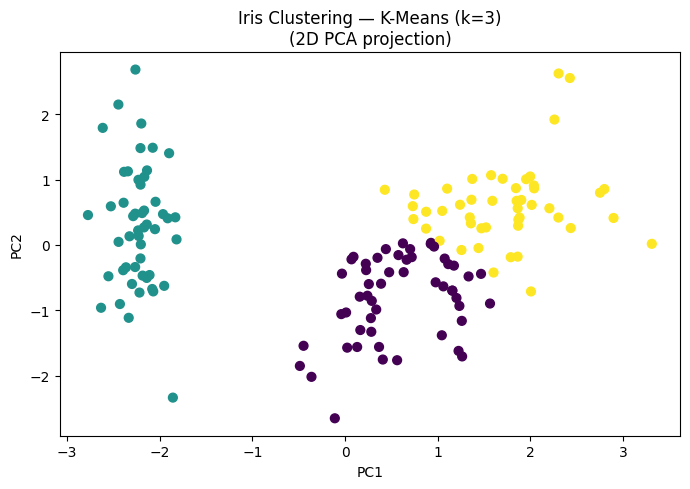

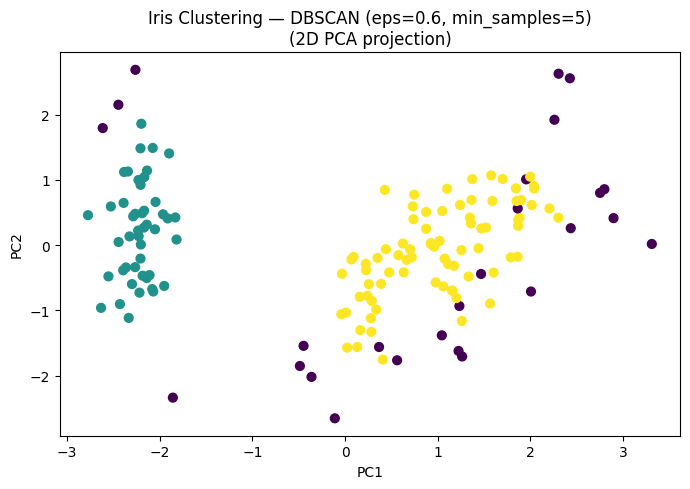

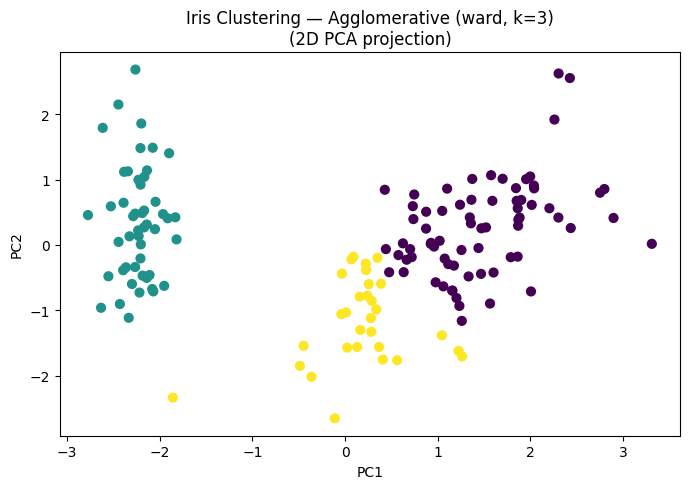

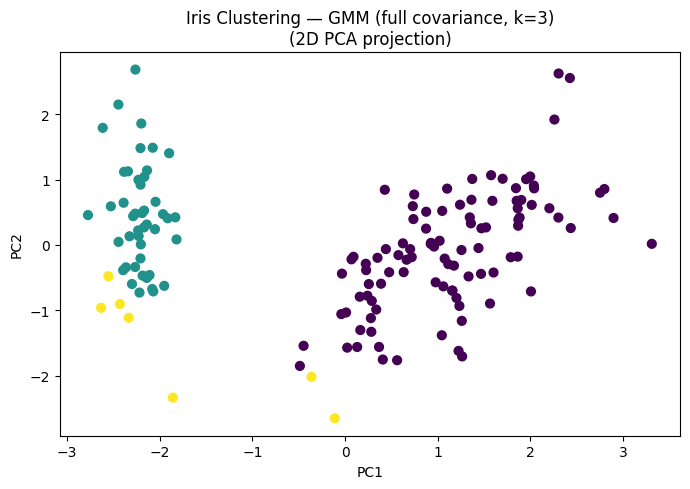

                         Algorithm  Silhouette  Davies-Bouldin
0                    K-Means (k=3)    0.459948        0.833595
1  DBSCAN (eps=0.6, min_samples=5)    0.641895        0.512052
2        Agglomerative (ward, k=3)    0.446689        0.803467
3       GMM (full covariance, k=3)    0.475143        0.886715


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score

iris = load_iris(as_frame=True)
X = iris.data

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

def clustering_metrics(X_full, labels):
    labels = np.asarray(labels)
    unique = set(labels)
    if len(unique) <= 1:
        return np.nan, np.nan
    if -1 in unique:
        mask = labels != -1
        labels_nn = labels[mask]
        if len(set(labels_nn)) <= 1:
            return np.nan, np.nan
        return (silhouette_score(X_full[mask], labels_nn),
                davies_bouldin_score(X_full[mask], labels_nn))
    return (silhouette_score(X_full, labels),
            davies_bouldin_score(X_full, labels))

models = {
    "K-Means (k=3)": KMeans(n_clusters=3, n_init=10, random_state=42),
    "DBSCAN (eps=0.6, min_samples=5)": DBSCAN(eps=0.6, min_samples=5),
    "Agglomerative (ward, k=3)": AgglomerativeClustering(n_clusters=3, linkage="ward"),
    "GMM (full covariance, k=3)": GaussianMixture(n_components=3, covariance_type="full", random_state=42),
}

results = {}
for name, model in models.items():
    labels = model.fit_predict(X_scaled)
    results[name] = labels

for name, labels in results.items():
    plt.figure(figsize=(7,5))
    plt.scatter(X_2d[:,0], X_2d[:,1], c=labels, s=40)
    plt.title(f"Iris Clustering — {name}\n(2D PCA projection)")
    plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()

rows = []
for name, labels in results.items():
    sil, db = clustering_metrics(X_scaled, labels)
    rows.append({"Algorithm": name, "Silhouette": sil, "Davies-Bouldin": db})
print(pd.DataFrame(rows))
